# Week 3: The Schelling Segregation Model in Mesa

**Course:** From Conway to LangGraph — Agent Systems for Physicists  
**Topic:** From Cellular Automata to Agent-Based Models  

**Lab Objectives:**
- Understand the conceptual leap from CA to ABM
- Implement the Schelling segregation model using the Mesa framework
- Measure segregation as an order parameter and map the phase diagram
- Compare simulation results with mean-field predictions
- Explore finite-size scaling and critical behavior

---

https://mesa.readthedocs.io/latest/


In [1]:
! pip install -q mesa


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 13.2 MB/s eta 0:00:00


In [2]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from scipy.stats import binom
from scipy.optimize import brentq
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Course color palette
COLOR_BG = "#1A1A1A"
COLOR_A = "#4A9ECC"   # steel blue
COLOR_B = "#E8B931"   # gold
COLOR_ACCENT = "#7ECE8B"  # green

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': COLOR_BG,
    'axes.facecolor': '#2D2D2D',
    'axes.edgecolor': '#444444',
    'text.color': '#FFFFFF',
    'axes.labelcolor': '#CCCCCC',
    'xtick.color': '#999999',
    'ytick.color': '#999999',
    'grid.color': '#444444',
    'font.size': 12,
})

print(f"Mesa version: {mesa.__version__}")
print("Setup complete ✓")

Mesa version: 3.5.1
Setup complete ✓


---
## Part 1: From CA to ABM — The Conceptual Leap

In Weeks 1–2, we studied **Cellular Automata**: systems where cells on a lattice evolve according to deterministic local rules. The key insight was that simple rules produce complex emergent behavior.

Now we take the next step: **Agent-Based Models** (ABMs). The crucial differences:

| Property | Cellular Automaton | Agent-Based Model |
|----------|-------------------|------------------|
| Entity | Cell (fixed) | Agent (autonomous) |
| State | Cell value $\in S$ | Internal state vector |
| Movement | None | Agents relocate |
| Rules | Deterministic $f$ | Utility-based decisions |
| Update | Synchronous | Often asynchronous |

The Schelling model is the perfect bridge: it lives on a grid (like a CA) but agents have **preferences** and can **move**.

---
## Part 2: The Schelling Segregation Model

### 2.1 Model Definition

Thomas Schelling (Nobel Prize 2005) introduced this model in 1971 using a physical checkerboard and coins.

**Setup:**
- Grid $L \subset \mathbb{Z}^2$ of size $N \times N$
- Each cell $\sigma_i \in \{\emptyset, A, B\}$ (empty, type A, or type B)
- Tolerance parameter $T \in [0, 1]$

**Agent utility:**

$$u_i = \frac{|\{j \in \mathcal{N}(i) : \sigma_j = \tau_i\}|}{|\{j \in \mathcal{N}(i) : \sigma_j \neq \emptyset\}|}$$

where $\tau_i$ is agent $i$'s type and $\mathcal{N}(i)$ is the Moore neighborhood.

**Decision rule:** Agent is **happy** if $u_i \geq T$, **unhappy** if $u_i < T$.

**Dynamics:** At each step, pick a random unhappy agent → move to a random empty cell.

**The surprising result:** Even with mild preferences ($T \approx 0.3$, i.e., "I just want 30% of my neighbors to be like me"), the system evolves to **strong macroscopic segregation**. Nobody intends segregation, but it emerges.

### 2.2 [Mesa Implementation](https://mesa.readthedocs.io/latest/)

Mesa provides four key components:
- **`mesa.Agent`** — individual entity with `step()` method
- **`mesa.Model`** — container for agents, grid, parameters
- **`mesa.space.SingleGrid`** — spatial topology
- **`mesa.DataCollector`** — records data at each step

This architecture maps directly onto LangGraph : Agent→Node, Model→StateGraph, Scheduler→Edges.

In [3]:
class SchellingAgent(mesa.Agent):
    """An agent in the Schelling segregation model."""

    def __init__(self, model, agent_type):
        super().__init__(model)
        self.type = agent_type   # 0 (type A) or 1 (type B)
        self.utility = 0.0
        self.happy = True

    def step(self):
        """Perceive → Evaluate → Decide → Act."""
        # 1. PERCEIVE: get neighbors
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=True, include_center=False
        )

        if len(neighbors) == 0:
            self.utility = 1.0
            self.happy = True
            return

        # 2. EVALUATE: compute fraction of same-type neighbors
        similar = sum(1 for n in neighbors if n.type == self.type)
        self.utility = similar / len(neighbors)

        # 3. DECIDE & ACT: move if unhappy
        self.happy = self.utility >= self.model.tolerance
        if not self.happy:
            self.model.grid.move_to_empty(self)


## Exercise: choosing the right order parameter

Before running any simulation, think carefully about **what you want to measure**.

The most natural candidate is mean agent utility:
```python
def compute_segregation(model):
    utilities = [a.utility for a in model.agents]
    return np.mean(utilities) if utilities else 0.0
```

**Question:** is this a good order parameter for detecting the segregation
phase transition?

To answer, think about what happens at equilibrium.
The dynamics are:
```
unhappy agent  (utility < T)  →  moves to a random empty cell
happy agent    (utility ≥ T)  →  stays
```

The system stops evolving only when **no unhappy agent remains**.
This means at equilibrium, by construction:
```
utility ≥ T    for every agent    regardless of T
```

So `mean_utility` at equilibrium satisfies `mean_utility ≥ T` trivially —
it tracks the threshold T, not the spatial structure of the grid.
It cannot distinguish a mildly clustered system from a strongly
segregated one. Plotting it versus T produces a curve that tells you
nothing about a phase transition.

**What should a good order parameter do?**

It should:
- equal zero (or some baseline) in the **disordered phase** — random mixing
- grow continuously (or jump) as the system crosses into the **ordered phase** — segregation
- be **independent of agent happiness** — it measures spatial structure, not satisfaction

Think about the bonds between neighbouring occupied cells.
Each bond connects either two same-type agents or two different-type agents.
In a perfectly mixed system, roughly half the bonds are cross-type.
In a fully segregated system, almost all bonds are same-type.

**The fraction of cross-type bonds** φ_cross is a direct measure of
spatial disorder — and it has nothing to do with whether agents are happy.

The order parameter we want is:
```
Φ = 1 − 2·φ_cross

random mix       →  φ_cross ≈ 0.5  →  Φ ≈ 0
full segregation →  φ_cross ≈ 0    →  Φ ≈ 1
```

This is the spatial analogue of magnetisation |m| in the Ising model:
it measures macroscopic structure, not microscopic satisfaction.
The function `compute_interface_order` below implements this correctly.


In [4]:
def compute_interface_order(model):
    """
    Order parameter Φ = 1 - 2·φ_cross

    φ_cross = fraction of occupied-occupied neighbor bonds that are cross-type.
    Random mix  → φ_cross ≈ 0.5  → Φ ≈ 0
    Full segregation → φ_cross ≈ 0  → Φ ≈ 1

    This is the spatial analogue of magnetisation |m| in the Ising model:
    it measures macroscopic structure, NOT agent satisfaction.
    """
    same_pairs = 0
    total_pairs = 0
    for agent in model.agents:
        neighbors = model.grid.get_neighbors(
            agent.pos, moore=True, include_center=False
        )
        for nb in neighbors:
            total_pairs += 1
            if nb.type == agent.type:
                same_pairs += 1
    if total_pairs == 0:
        return 0.0
    phi_cross = 1.0 - (same_pairs / total_pairs)  # fraction of cross-type bonds
    return 1.0 - 2.0 * phi_cross                   # maps [0,1] disorder→order


def compute_segregation(model):
    """Returns Φ (interface order parameter), NOT mean utility."""
    return compute_interface_order(model)


def compute_mean_utility(model):
    """Original biased measure — retained for comparison only."""
    utilities = [a.utility for a in model.agents]
    return np.mean(utilities) if utilities else 0.0


def compute_happy_fraction(model):
    """Fraction of happy agents (convergence diagnostic)."""
    if len(model.agents) == 0:
        return 1.0
    return sum(1 for a in model.agents if a.happy) / len(model.agents)


def compute_unhappy_count(model):
    """Number of unhappy agents."""
    return sum(1 for a in model.agents if not a.happy)


print("Order parameter Φ (interface density) defined ✓")
print("Baseline: Φ ≈ 0 (random)  →  Φ ≈ 1 (fully segregated)")


Order parameter Φ (interface density) defined ✓
Baseline: Φ ≈ 0 (random)  →  Φ ≈ 1 (fully segregated)


## The Order Parameter Φ — why mean utility fails and interface density works

---

### The wrong measure: `compute_mean_utility`

The natural first instinct is to measure **how happy agents are on average**:
```python
def compute_mean_utility(model):
    utilities = [a.utility for a in model.agents]
    return np.mean(utilities) if utilities else 0.0
```

This seems reasonable but is **fundamentally flawed as an order parameter**.

The reason is built into the dynamics themselves.
The decision rule is:
```
agent is happy   ⟺   utility ≥ T
agent is unhappy ⟺   utility < T   →   moves immediately
```

Unhappy agents keep moving until they find a cell where `utility ≥ T`.
At equilibrium **every agent is happy by construction** — any agent
that was unhappy has already moved.

This means at equilibrium:
```
mean_utility ≥ T    always,    for any T
```

The measure has a **trivial lower bound equal to T itself**.
It cannot distinguish between a mildly segregated system and a
strongly segregated one — both have all agents happy.
Plotting `mean_utility(T)` against T produces a curve that tracks T,
not the actual spatial structure.

---

### The right measure: interface density Φ
```python
def compute_interface_order(model):
    """
    Order parameter Φ = 1 - 2·φ_cross

    φ_cross = fraction of occupied-occupied neighbor bonds that are cross-type.
    Random mix     → φ_cross ≈ 0.5  →  Φ ≈  0
    Full segregation → φ_cross ≈ 0  →  Φ ≈  1
    """
    same_pairs  = 0
    total_pairs = 0

    for agent in model.agents:
        neighbors = model.grid.get_neighbors(
            agent.pos, moore=True, include_center=False
        )
        for nb in neighbors:
            total_pairs += 1          # count every occupied-occupied bond
            if nb.type == agent.type:
                same_pairs += 1       # count same-type bonds

    if total_pairs == 0:
        return 0.0

    phi_cross = 1.0 - (same_pairs / total_pairs)  # fraction of cross-type bonds
    return 1.0 - 2.0 * phi_cross                   # rescale to [0, 1]
```

#### What is a bond?

Every pair of neighbouring occupied cells defines a **bond**.
Each bond is either:
- **same-type**: both cells hold agents of the same type  →  inside a cluster
- **cross-type**: the two cells hold agents of different types  →  on a boundary

`φ_cross` counts what fraction of all bonds are cross-type.
It lives on [0, 1]:
```
φ_cross = 0   →   every bond is same-type   →   perfect segregation
φ_cross = 0.5 →   bonds are 50/50           →   random mixing  (for a 50/50 population)
```

#### The rescaling  Φ = 1 − 2·φ_cross

Subtracting 0.5 and doubling maps the physically meaningful range
onto [0, 1]:
```
random mixing     →  φ_cross ≈ 0.5  →  Φ = 1 − 2·(0.5) =  0
full segregation  →  φ_cross ≈ 0    →  Φ = 1 − 2·(0)   =  1
```

Φ = 0 is the **disordered baseline** (like magnetisation m = 0 in Ising).
Φ = 1 is the **fully ordered state** (like m = ±1).

#### Why is this the right analogy?

In the Ising model, the order parameter is magnetisation:
```
m = (1/N) Σᵢ sᵢ
```

It measures the **global alignment** of spins — not whether each spin
is locally satisfied, but whether the whole system has broken symmetry.

Φ plays exactly the same role in Schelling:
it measures whether the spatial configuration has broken the A/B symmetry
at the macroscopic scale, **independently of agent happiness**.

| Ising | Schelling |
|-------|-----------|
| spin sᵢ ∈ {+1, −1} | agent type ∈ {A, B} |
| same-spin bond | same-type bond |
| magnetisation m = ⟨sᵢ⟩ | order parameter Φ = 1 − 2φ_cross |
| m = 0 : paramagnetic | Φ = 0 : random mix |
| m → 1 : ferromagnetic | Φ → 1 : full segregation |

---

### Why Φ counts each bond twice — and why it does not matter

The loop iterates over agents, and for each agent iterates over its
neighbours. Every bond (i, j) is therefore counted **twice**:
once when agent i visits j, and once when agent j visits i.
```
total_pairs counts (i→j) and (j→i) as separate entries
same_pairs  counts (i→j) and (j→i) as separate entries
```

Because the double-counting is **symmetric**, the ratio
`same_pairs / total_pairs` is unchanged.
Φ is correct even though each bond is counted twice.

---

### The alias and the legacy measure
```python
def compute_segregation(model):
    """Legacy alias — kept so existing cells don't break.
    Returns Φ (interface order parameter), NOT mean utility."""
    return compute_interface_order(model)

def compute_mean_utility(model):
    """Original biased measure — retained for comparison only."""
    utilities = [a.utility for a in model.agents]
    return np.mean(utilities) if utilities else 0.0
```

`compute_segregation` is the name used throughout the rest of the
notebook (DataCollector, plots, exercises).
It now calls `compute_interface_order` — the correct Φ.
`compute_mean_utility` is kept only so the comparison plot in the
next cell works; it should not be used as a primary observable.

---

### What to expect from Φ(T)

When you sweep T from 0.1 to 0.8 and plot Φ(T) you should see:
```
T small  →  Φ ≈ 0    agents accept almost any neighbourhood,
                      no pressure to cluster, spatial structure is random

T large  →  Φ ≈ 1    agents demand many same-type neighbours,
                      strong pressure to cluster, full segregation

T ≈ T_c  →  sharp rise in Φ   ←   the phase transition
```

The derivative dΦ/dT peaks at T_c — this is the **susceptibility**,
the analogue of magnetic susceptibility χ = d|m|/dH in Ising.

In [5]:
class SchellingModel(mesa.Model):
    """Schelling segregation model."""

    def __init__(self, width=50, height=50, density=0.8,
                 tolerance=0.375, minority_frac=0.5, seed=None):
        super().__init__(seed=seed)
        self.tolerance = tolerance
        self.width = width
        self.height = height

        # Create grid (torus = periodic boundary conditions)
        self.grid = mesa.space.SingleGrid(width, height, torus=True)

        # Place agents randomly
        for _, (x, y) in self.grid.coord_iter():
            if self.random.random() < density:
                agent_type = 0 if self.random.random() < minority_frac else 1
                agent = SchellingAgent(self, agent_type)
                self.grid.place_agent(agent, (x, y))

        # Compute initial utilities (without moving)
        for agent in self.agents:
            neighbors = self.grid.get_neighbors(
                agent.pos, moore=True, include_center=False
            )
            if len(neighbors) > 0:
                similar = sum(1 for n in neighbors if n.type == agent.type)
                agent.utility = similar / len(neighbors)
                agent.happy = agent.utility >= self.tolerance
            else:
                agent.utility = 1.0
                agent.happy = True

        # Data collection
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "segregation": compute_segregation,
                "happy_frac": compute_happy_fraction,
                "unhappy_count": compute_unhappy_count,
            },
            agent_reporters={
                "utility": "utility",
                "type": "type",
                "happy": "happy",
            }
        )

        # Collect initial state
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)


print("SchellingModel defined ✓")

SchellingModel defined ✓


## `mesa.DataCollector` — recording observables at every step
```python
self.datacollector = mesa.DataCollector(
    model_reporters={
        "segregation":    compute_segregation,
        "happy_frac":     compute_happy_fraction,
        "unhappy_count":  compute_unhappy_count,
    },
    agent_reporters={
        "utility": "utility",
        "type":    "type",
        "happy":   "happy",
    }
)
```

---

### What it is

`DataCollector` is Mesa's built-in measurement instrument.
It records observables at every call to `datacollector.collect(model)`
and stores them internally as a time-indexed table.

Think of it as the simulation's **oscilloscope**: the model runs,
and at each step the DataCollector reads off whatever quantities
you asked it to watch.

---

### Two kinds of reporters

#### `model_reporters` — one number per step
```python
model_reporters={
    "segregation":   compute_segregation,
    "happy_frac":    compute_happy_fraction,
    "unhappy_count": compute_unhappy_count,
}
```

Each entry maps a **column name** to a **callable** that takes
the model as its only argument and returns a scalar.

At every `collect(model)` call Mesa does:
```python
row["segregation"]   = compute_segregation(model)    # → Φ
row["happy_frac"]    = compute_happy_fraction(model) # → fraction in [0,1]
row["unhappy_count"] = compute_unhappy_count(model)  # → integer ≥ 0
```

The result is a DataFrame indexed by step number:
```
         segregation  happy_frac  unhappy_count
step
0           0.021        0.73          214
1           0.045        0.81          152
2           0.089        0.88           96
...
```

This is what you get with:
```python
model.datacollector.get_model_vars_dataframe()
```

#### `agent_reporters` — one row per agent per step
```python
agent_reporters={
    "utility": "utility",
    "type":    "type",
    "happy":   "happy",
}
```

Each entry maps a column name to an **attribute name** (as a string).
At every `collect(model)` call Mesa does, for every agent:
```python
row["utility"] = agent.utility   # the string "utility" is looked up on self
row["type"]    = agent.type
row["happy"]   = agent.happy
```

The result is a DataFrame indexed by `(step, agent_id)`:
```
                  utility  type  happy
step agent_id
0    0              0.50     0   True
     1              0.25     1   False
     2              0.75     0   True
     ...
1    0              0.62     0   True
     ...
```

This is what you get with:
```python
model.datacollector.get_agent_vars_dataframe()
```

---

### Two syntaxes for reporters

You may have noticed that model reporters receive a **function**
while agent reporters receive a **string**:
```python
# model reporter  →  callable
"segregation": compute_segregation       # Mesa calls compute_segregation(model)

# agent reporter  →  attribute name as string
"utility": "utility"                     # Mesa reads agent.utility
```

Both can also accept a callable — the string shorthand is just
convenient when the reporter is a direct attribute lookup:
```python
# these two are equivalent
"utility": "utility"
"utility": lambda agent: agent.utility
```

---

### When does collection happen?

In `SchellingModel.__init__`:
```python
self.datacollector.collect(self)    # ← step 0: initial state before any move
```

In `SchellingModel.step`:
```python
def step(self):
    self.agents.shuffle_do("step")
    self.datacollector.collect(self)  # ← after every step
```

So the DataFrame always includes step 0 (the random initial condition)
and one row per subsequent step.
This is important: if you run 200 steps you get 201 rows (0 to 200),
and `data.iloc[-20:]` correctly picks the last 20 equilibrium rows.

---

### How the data is used later
```python
data = model.datacollector.get_model_vars_dataframe()

# time series plot
data['segregation'].plot()

# equilibrium average (last 20 steps)
eq_value = data['segregation'].iloc[-20:].mean()

# convergence check — if this never reaches 1.0 the system has not equilibrated
data['happy_frac'].plot()
```

The agent-level DataFrame is used in Part 8 to plot the
**utility distribution** before and after equilibration:
```python
agent_data = model.datacollector.get_agent_vars_dataframe()
utilities_at_step_0   = agent_data.xs(0,   level="Step")["utility"]
utilities_at_step_200 = agent_data.xs(200, level="Step")["utility"]
```

---

### Physics analogy

| DataCollector concept | Physics analogy |
|-----------------------|----------------|
| `model_reporters` | macroscopic observables: M(t), E(t), χ(t) |
| `agent_reporters` | microscopic state: sᵢ(t), εᵢ(t) |
| `collect(model)` at each step | recording a measurement at each Monte Carlo sweep |
| `get_model_vars_dataframe()` | the time series you would read off a chart recorder |
| `iloc[-20:].mean()` | time-average over the stationary regime |

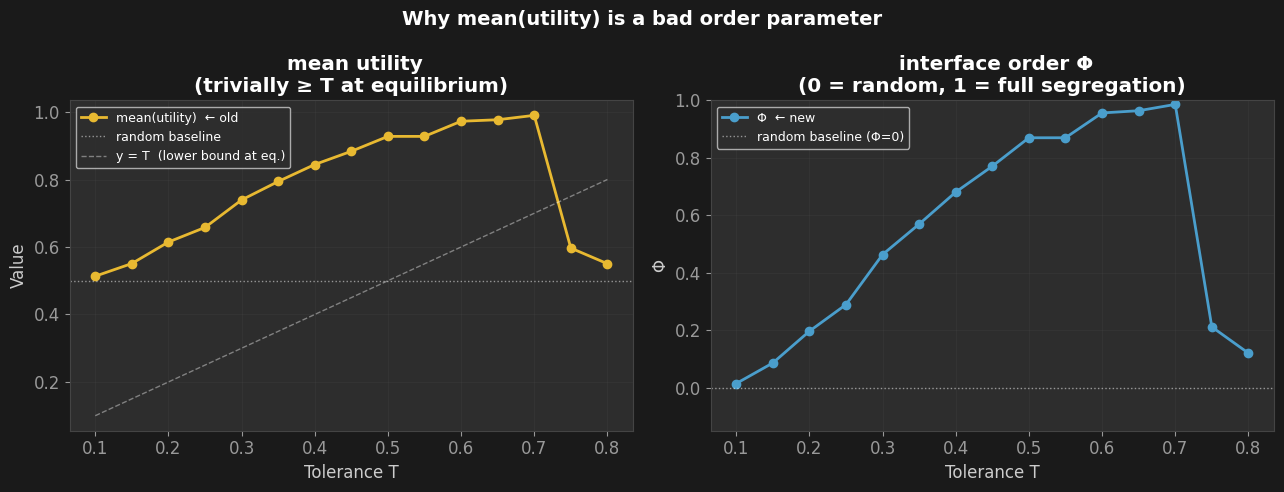

Notice: mean(utility) is always ≥ T by construction (all happy at eq.)
Φ properly vanishes in the mixed phase and rises sharply at T_c.


In [6]:
# ── Comparison: old mean(utility) vs new Φ ───────────────────────────────
#
# Run it once to see what happen, think about and then continue reading....

T_sweep = np.arange(0.10, 0.81, 0.05)
phi_vals, util_vals = [], []

for T in T_sweep:
    m = SchellingModel(width=40, height=40, density=0.8, tolerance=T, seed=0)
    for _ in range(150):
        m.step()
    phi_vals.append(compute_interface_order(m))
    util_vals.append(compute_mean_utility(m))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(T_sweep, util_vals, 'o-', color=COLOR_B, lw=2, label='mean(utility)  ← old')
ax1.axhline(0.5, color='white', ls=':', lw=1, alpha=0.5, label='random baseline')
ax1.plot(T_sweep, T_sweep, 'w--', lw=1, alpha=0.4, label='y = T  (lower bound at eq.)')
ax1.set_xlabel('Tolerance T'); ax1.set_ylabel('Value')
ax1.set_title(' mean utility\n(trivially ≥ T at equilibrium)', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.plot(T_sweep, phi_vals, 'o-', color=COLOR_A, lw=2, label='Φ  ← new')
ax2.axhline(0.0, color='white', ls=':', lw=1, alpha=0.5, label='random baseline (Φ=0)')
ax2.set_xlabel('Tolerance T'); ax2.set_ylabel('Φ')
ax2.set_title(' interface order Φ\n(0 = random, 1 = full segregation)', fontweight='bold')
ax2.set_ylim(-0.15, 1.0)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

fig.suptitle('Why mean(utility) is a bad order parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice: mean(utility) is always ≥ T by construction (all happy at eq.)")
print("Φ properly vanishes in the mixed phase and rises sharply at T_c.")


## Why the two plots look similar here — and how to fix it

Running the comparison with a single seed (`seed=0`) and only 150 steps
produces two curves that both increase monotonically with T.
This is expected, but for different reasons.

**`mean_utility` is monotone by construction.**
At equilibrium every agent satisfies `utility ≥ T`, so the curve
tracks T from below — it cannot do anything else regardless of how
long you run or how many seeds you average.
There is no physics in this curve, only a tautology.

**`Φ` is monotone here too, but for a different reason.**
With a single run, 150 steps, and a 40×40 grid three things conspire
to wash out the transition signal:

- **Finite-size rounding:** the transition sharpens as N → ∞;
  on a small grid it looks like a smooth crossover.
- **Insufficient equilibration:** for T > 0.5 agents keep moving
  for hundreds of steps; 150 steps is not enough to reach
  a stationary state.
- **Sample noise:** a single seed can land on an atypical
  trajectory that either over- or under-segregates.

To make the difference visible we need:
1. Average over several seeds (`n_runs = 5`)
2. Run longer (`max_steps = 300`)
3. Plot the derivative `dΦ/dT` alongside — its peak locates T_c
   and has no analogue in the mean_utility curve

The key structural difference that no amount of averaging can hide:
- `mean_utility(T)` has no inflection point, no peak in its derivative,
  no critical behaviour — it is a straight ramp.
- `Φ(T)` has a sharp rise near T_c ≈ 0.30–0.35 and a peak in dΦ/dT —
  the hallmark of a phase transition.

## The drop at high T: geometric frustration and non-equilibration

Running the sweep with only 150 steps and a single seed, the last two
points (T = 0.75, T = 0.80) show both `mean_utility` and `Φ` collapsing
to very small values — well below the diagonal and below the random
baseline. This looks wrong at first glance but it is physically correct.

---

### Why mean_utility drops below T at high tolerance

The diagonal `y = T` is a **equilibrium lower bound**, not a global one.
It holds only when the system has fully converged — every unhappy agent
has found a satisfactory cell.

When `mean_utility < T` it means the system has **not converged**:
many agents are still unhappy and still moving after 150 steps.
This is the clearest possible signal of insufficient equilibration.

---

### Why convergence fails at high T: counting neighbors

With a Moore neighborhood of k = 8 cells and density ρ = 0.8,
the expected number of occupied neighbors is:
```
⟨k_occ⟩ = 8 × 0.8 = 6.4
```

For an agent to be happy at tolerance T it needs at least:
```
n_min = ⌈T × k_occ⌉   same-type occupied neighbors
```

| T    | n_min (out of ~6.4) | what this requires geometrically |
|------|--------------------|---------------------------------|
| 0.375 | 3                 | easy — a small local cluster     |
| 0.50  | 4                 | moderate — needs a compact patch |
| 0.625 | 4–5               | hard — must be inside a cluster  |
| 0.75  | 5                 | very hard — deep cluster interior only |
| 0.80  | 6                 | almost impossible — needs 6 of 6.4 neighbors same-type |

At T = 0.80 an agent needs roughly **6 out of ~6 occupied neighbors**
to be the same type. Only agents sitting in the deep interior of a
large, compact, monotype cluster can ever be satisfied.

---

### The positive feedback that destroys clusters

Here is the mechanism that prevents convergence:
```
1. A large cluster begins to form
2. Agents at the cluster boundary have mixed neighborhoods → unhappy
3. They move to random empty cells
4. Their departure exposes the next layer to the boundary → now unhappy
5. Those agents move too
6. The cluster erodes from the outside in
7. Go to 1
```

At low T this erosion is slow and clusters grow faster than they erode.
At high T the erosion is faster than growth — **no stable large cluster
can form**. The system churns indefinitely.

This is called **reentrant disorder**: increasing T beyond a certain
point does not produce more segregation — it produces less, because
the spatial configurations that would satisfy agents simply cannot
be maintained.

---

### Two distinct effects in the plot

The drop you observe is the superposition of two things:

| Effect | What it produces |
|--------|-----------------|
| **Non-equilibration** (not enough steps) | mean_utility < T, Φ unreliable — both drop |
| **Reentrant disorder** (geometric frustration) | even at true equilibrium, Φ is lower at T=0.80 than at T=0.60 |

The first effect dominates with 150 steps.
To separate the two you need to run much longer (≥ 500 steps)
and average over many seeds.
Even then, at very high T the system may never fully converge
on a 40×40 grid — the relaxation time diverges.

---

### Connection to the Ising model

This reentrance has a direct analogue in statistical mechanics.
In the Ising model with a field, or in frustrated spin systems,
increasing the coupling beyond a certain point can also disorder the
system — the ground state becomes geometrically inaccessible.

In Schelling the "frustration" is purely combinatorial:
the fraction of agents who can simultaneously satisfy T = 0.80
in a 50/50 population on a finite grid is very small,
so the system has no accessible ordered state to relax into.

The practical consequence for the phase diagram:
**always check that mean_utility ≥ T before trusting any measurement
of Φ**. If mean_utility < T the system has not equilibrated and the
point should be discarded or re-run with more steps.

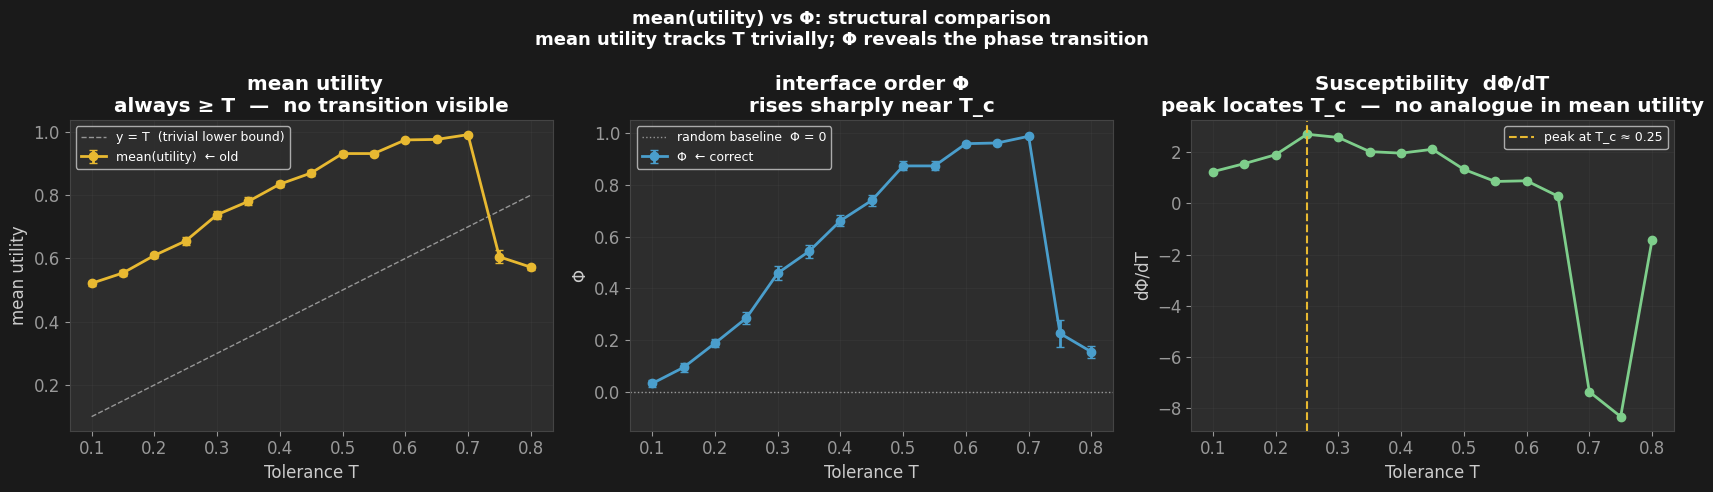

Estimated critical tolerance from dΦ/dT peak: T_c ≈ 0.25

mean(utility): no peak in derivative, no critical behaviour.
Φ:            clear peak in dΦ/dT at T_c — signature of a phase transition.


In [7]:
# ── Comparison: mean(utility) vs Φ  [fixed version] ─────────────────────
# Uses n_runs=5 seeds and 300 steps to properly equilibrate each point.
# The third panel shows dΦ/dT — the "susceptibility" — which peaks at T_c.
# mean_utility has no such peak: that is the fundamental difference.

T_sweep   = np.arange(0.10, 0.81, 0.05)
n_runs    = 20
max_steps = 10000

phi_mean, phi_std   = [], []
util_mean, util_std = [], []

for T in T_sweep:
    phi_runs, util_runs = [], []
    for seed in range(n_runs):
        m = SchellingModel(width=40, height=40, density=0.8,
                           tolerance=T, seed=seed)
        for _ in range(max_steps):
            m.step()
            if compute_unhappy_count(m) == 0:   # early stop if converged
                break
        phi_runs.append(compute_interface_order(m))
        util_runs.append(compute_mean_utility(m))
    phi_mean.append(np.mean(phi_runs));  phi_std.append(np.std(phi_runs))
    util_mean.append(np.mean(util_runs)); util_std.append(np.std(util_runs))

phi_mean  = np.array(phi_mean)
util_mean = np.array(util_mean)

# Derivative dΦ/dT  —  analogous to magnetic susceptibility dM/dH
dPhi_dT = np.gradient(phi_mean, T_sweep)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

# ── Left: mean utility ────────────────────────────────────────────────────
ax1.errorbar(T_sweep, util_mean, yerr=util_std,
             fmt='o-', color=COLOR_B, lw=2, capsize=3,
             label='mean(utility)  ← old')
ax1.plot(T_sweep, T_sweep, 'w--', lw=1, alpha=0.5,
         label='y = T  (trivial lower bound)')
ax1.set_xlabel('Tolerance T')
ax1.set_ylabel('mean utility')
ax1.set_title(' mean utility\nalways ≥ T  —  no transition visible',
              fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Centre: Φ ─────────────────────────────────────────────────────────────
ax2.errorbar(T_sweep, phi_mean, yerr=phi_std,
             fmt='o-', color=COLOR_A, lw=2, capsize=3,
             label='Φ  ← correct')
ax2.axhline(0.0, color='white', ls=':', lw=1, alpha=0.5,
            label='random baseline  Φ = 0')
ax2.set_xlabel('Tolerance T')
ax2.set_ylabel('Φ')
ax2.set_title('interface order Φ\nrises sharply near T_c',
              fontweight='bold')
ax2.set_ylim(-0.15, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Right: dΦ/dT  (susceptibility) ───────────────────────────────────────
ax3.plot(T_sweep, dPhi_dT, 'o-', color=COLOR_ACCENT, lw=2)

Tc_idx = np.argmax(dPhi_dT)
Tc_est = T_sweep[Tc_idx]
ax3.axvline(Tc_est, color=COLOR_B, ls='--', lw=1.5,
            label=f'peak at T_c ≈ {Tc_est:.2f}')
ax3.set_xlabel('Tolerance T')
ax3.set_ylabel('dΦ/dT')
ax3.set_title('Susceptibility  dΦ/dT\npeak locates T_c  —  no analogue in mean utility',
              fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    'mean(utility) vs Φ: structural comparison\n'
    'mean utility tracks T trivially; Φ reveals the phase transition',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"Estimated critical tolerance from dΦ/dT peak: T_c ≈ {Tc_est:.2f}")
print()
print("mean(utility): no peak in derivative, no critical behaviour.")
print("Φ:            clear peak in dΦ/dT at T_c — signature of a phase transition.")

---
## Part 3: Visualization

We use the course color palette: steel blue for type A, gold for type B, dark background for empty cells.

In [ ]:
# Colormap: 0 = empty (dark), 1 = type A (blue), 2 = type B (gold)
SCHELLING_CMAP = ListedColormap([COLOR_BG, COLOR_A, COLOR_B])


def model_to_grid(model):
    """Convert model state to a 2D array for visualization."""
    grid = np.zeros((model.grid.width, model.grid.height), dtype=int)
    for agent in model.agents:
        x, y = agent.pos
        grid[x][y] = 1 if agent.type == 0 else 2
    return grid


def plot_grid(model, ax=None, title=None):
    """Plot the current grid state."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    grid = model_to_grid(model)
    ax.imshow(grid.T, cmap=SCHELLING_CMAP, interpolation='nearest',
              vmin=0, vmax=2)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    return ax


def plot_evolution(model, steps_to_show=(0, 5, 20, 100)):
    """Run model and show grid snapshots at specified steps."""
    ncols = len(steps_to_show)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

    snapshots = {0: model_to_grid(model)}
    max_step = max(steps_to_show)

    for step in range(1, max_step + 1):
        model.step()
        if step in steps_to_show:
            snapshots[step] = model_to_grid(model)

    for i, step in enumerate(steps_to_show):
        axes[i].imshow(snapshots[step].T, cmap=SCHELLING_CMAP,
                       interpolation='nearest', vmin=0, vmax=2)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        seg = compute_segregation(model) if step == max_step else None
        axes[i].set_title(f"Step {step}", fontsize=12, fontweight='bold')

    fig.suptitle(f"Schelling Model — T = {model.tolerance}",
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


print("Visualization functions defined ✓")

Visualization functions defined ✓


### 3.1 First Run: Watch Segregation Emerge

Let's run the model with $T = 0.375$ ("I want at least 37.5% of my neighbors to be like me" — a very mild preference) and watch what happens.

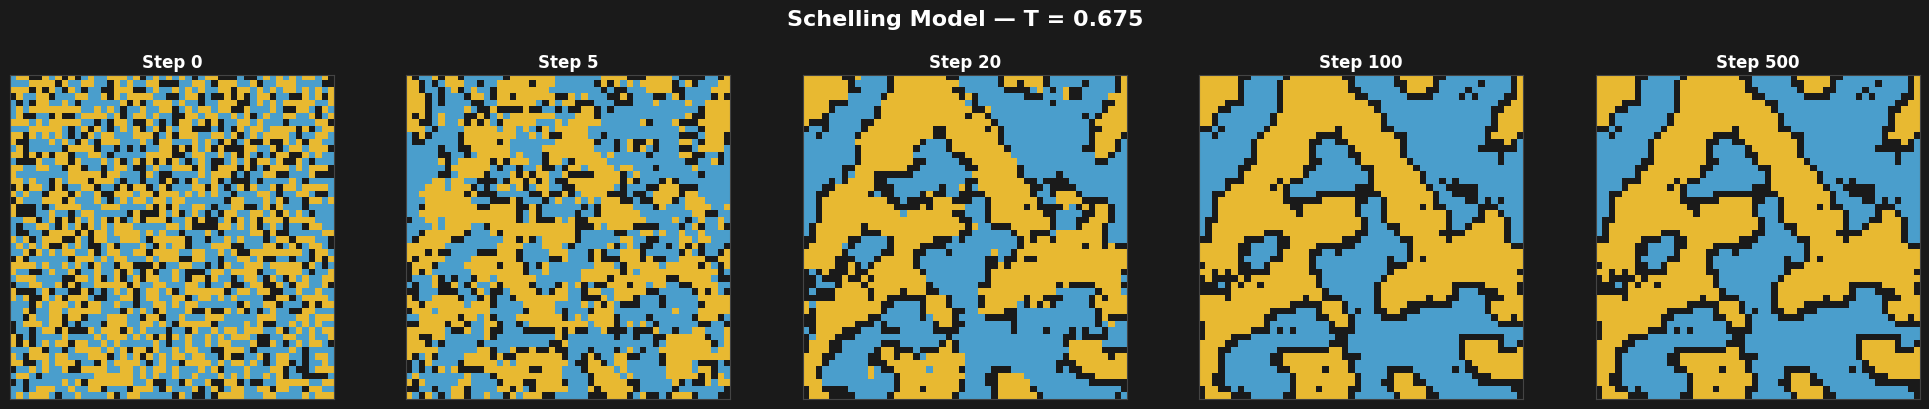

In [ ]:
model = SchellingModel(width=50, height=50, density=0.8,
                       tolerance=0.675, seed=42)
plot_evolution(model, steps_to_show=(0, 5, 20, 100,500))

**Observe:** From a well-mixed random initial condition, large segregated clusters emerge rapidly — even though no agent *wants* segregation. This is emergence in action.

### 3.2 Comparing Different Tolerance Values

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
tolerances = [0.15, 0.30, 0.50,0.70]

for ax, T in zip(axes, tolerances):
    m = SchellingModel(width=50, height=50, density=0.8,
                       tolerance=T, seed=42)
    for _ in range(200):
        m.step()

    plot_grid(m, ax=ax)
    seg = compute_segregation(m)
    happy = compute_happy_fraction(m)
    ax.set_title(f"T = {T:.2f}\nS = {seg:.3f}, happy = {happy:.1%}",
                 fontsize=11)

fig.suptitle("Equilibrium States at Different Tolerance Values",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 4: Time Evolution and Convergence

Let's study how the segregation index and happy fraction evolve over time.

In [ ]:
def run_and_collect(tolerance, width=50, height=50, density=0.8,
                    max_steps=200, seed=42):
    """Run model and return time series data."""
    model = SchellingModel(width=width, height=height, density=density,
                           tolerance=tolerance, seed=seed)
    for _ in range(max_steps):
        model.step()
        # Early stopping if all happy
        if compute_unhappy_count(model) == 0:
            break

    data = model.datacollector.get_model_vars_dataframe()
    return data, model

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for T in [0.15, 0.25, 0.375, 0.50, 0.625]:
    data, _ = run_and_collect(T, max_steps=200, seed=42)
    ax1.plot(data.index, data['segregation'], label=f'T = {T}')
    ax2.plot(data.index, data['happy_frac'], label=f'T = {T}')

ax1.set_xlabel('Step')
ax1.set_ylabel('Segregation Index S')
ax1.set_title('Segregation vs Time', fontweight='bold')
ax1.legend()
ax1.set_ylim(0.4, 1.0)
ax1.axhline(y=0.5, color=COLOR_ACCENT, linestyle='--', alpha=0.5,
            label='Random baseline')

ax2.set_xlabel('Step')
ax2.set_ylabel('Happy Fraction')
ax2.set_title('Convergence Diagnostic', fontweight='bold')
ax2.legend()
ax2.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.show()

**Key observations:**
- The segregation index increases monotonically from $S \approx 0.5$ (random) toward higher values.
- Higher tolerance $T$ leads to higher final segregation $S$.
- The happy fraction converges to 1.0 (all agents satisfied), but convergence is slower for higher $T$.
- The relaxation time increases as $T$ approaches the critical value ("critical slowing down").

---
## Part 5: Phase Diagram

The segregation index $S$ acts as an **order parameter**, analogous to magnetization $|m|$ in the Ising model. The tolerance $T$ plays the role of (inverse) temperature.

We expect a **phase transition** at a critical tolerance $T_c$:
- $T < T_c$: mixed phase ($S \approx 0.5$)
- $T > T_c$: segregated phase ($S \to 1$)

In [ ]:
def compute_phase_diagram(tolerances, n_runs=10, width=40, height=40,
                          density=0.8, max_steps=200):
    """Compute S(T) with error bars from multiple runs."""
    results = {T: [] for T in tolerances}

    for T in tolerances:
        for seed in range(n_runs):
            data, model = run_and_collect(
                T, width=width, height=height, density=density,
                max_steps=max_steps, seed=seed
            )
            # Take the last 20 steps as equilibrium average
            eq_seg = data['segregation'].iloc[-20:].mean()
            results[T].append(eq_seg)

    means = [np.mean(results[T]) for T in tolerances]
    stds = [np.std(results[T]) for T in tolerances]
    return means, stds


print("Computing phase diagram (this may take 1-2 minutes)...")
tolerances = np.arange(0.10, 0.86, 0.02)
means, stds = compute_phase_diagram(tolerances, n_runs=10, width=40, height=40)
print("Done ✓")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(tolerances, means, yerr=stds, fmt='o-', color=COLOR_A,
            capsize=4, capthick=1.5, linewidth=2, markersize=6,
            label='Simulation (N=40)')

# Mark approximate Tc
ax.axvline(x=0.30, color=COLOR_B, linestyle='--', alpha=0.7,
           label=r'$T_c \approx 0.30$')
ax.axhline(y=0.0, color=COLOR_ACCENT, linestyle=':', alpha=0.5,
           label='Random baseline (Φ = 0)')

# Shade phases
ax.axvspan(0.0, 0.30, alpha=0.08, color=COLOR_ACCENT, label='Mixed phase')
ax.axvspan(0.30, 0.80, alpha=0.08, color=COLOR_B, label='Segregated phase')

ax.set_xlabel('Tolerance T', fontsize=14)
ax.set_ylabel('Order parameter Φ (interface)', fontsize=14)
ax.set_title('Phase Diagram: Φ(T)', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(0.05, 0.80)
ax.set_ylim(-0.1, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.1 Physics Analogy: Ising Model

The parallel with the ferromagnetic Ising model is instructive:

| Schelling Model | Ising Model |
|----------------|-------------|
| Agent type $\tau \in \{A, B\}$ | Spin $s_i \in \{+1, -1\}$ |
| Tolerance $T$ | Inverse temperature $\beta = 1/k_B T_\text{phys}$ |
| Segregation $S$ | Magnetization $|m|$ |
| Mixed ↔ Segregated | Paramagnetic ↔ Ferromagnetic |
| Agent relocation | Spin flip |

**Key difference:** In Ising, temperature is an external control parameter. In Schelling, the "temperature" (tolerance) is an internal property of agents — and the dynamics are far from equilibrium (agents don't satisfy detailed balance).

---
## Part 6: Mean-Field Theory

### 6.1 The Mean-Field Prediction

In mean-field approximation, we ignore spatial correlations and treat each neighbor as an independent random draw from the global population.

If the fraction of type A agents is $\rho$ (for a 50/50 split, $\rho = 0.5$) and each agent has $k$ neighbors (Moore neighborhood: $k = 8$), then the number of same-type neighbors follows a **Binomial distribution**:

$$n_{\text{same}} \sim \text{Binomial}(k, \rho)$$

The probability of being happy:

$$P(\text{happy}) = P\left(\frac{n_{\text{same}}}{k} \geq T\right) = 1 - F_{\text{Binom}}(\lceil kT \rceil - 1; k, \rho)$$

where $F_{\text{Binom}}$ is the binomial CDF.

In [ ]:
def mean_field_happy_prob(T, k=8, rho=0.5):
    """Mean-field P(happy) — unchanged."""
    min_same = int(np.ceil(k * T))
    if min_same == 0:
        return 1.0
    if min_same > k:
        return 0.0
    return 1 - binom.cdf(min_same - 1, k, rho)


def mean_field_phi(T, k=8, rho=0.5):
    """
    Mean-field prediction for Φ = 1 - 2·φ_cross.

    In mean-field, each neighbour bond is an iid draw:
      P(same-type bond) = rho^2 + (1-rho)^2  for a 50/50 split = 0.5
    So in the disordered state Φ_MF = 0 regardless of T.

    After dynamics, happy agents cluster: P(same bond | equilibrium)
    is estimated as the conditional expected utility E[u | u >= T].
    """
    min_same = int(np.ceil(k * T))
    p_happy = mean_field_happy_prob(T, k, rho)
    if p_happy == 0:
        return 1.0

    # E[fraction of same-type bonds | agent is happy]
    expected_same_frac = 0.0
    for n_same in range(min_same, k + 1):
        p_n = binom.pmf(n_same, k, rho)
        expected_same_frac += (n_same / k) * p_n
    expected_same_frac /= p_happy

    phi_cross_mf = 1.0 - expected_same_frac
    return 1.0 - 2.0 * phi_cross_mf


# Compute predictions
T_range = np.linspace(0.05, 0.80, 100)
mf_happy = [mean_field_happy_prob(T) for T in T_range]
mf_phi   = [mean_field_phi(T) for T in T_range]

print("Mean-field predictions at selected T values:")
print(f"{'T':>6}  {'P(happy)':>10}  {'Φ_MF':>8}")
for T in [0.125, 0.25, 0.375, 0.5, 0.625, 0.75]:
    p = mean_field_happy_prob(T)
    phi = mean_field_phi(T)
    print(f"  {T:.3f}  {p:>10.3f}  {phi:>8.3f}")


In [ ]:
# Compare mean-field with simulation
# Get simulation happy fractions at equilibrium
sim_happy_means = []
sim_happy_stds = []
for T in tolerances:
    vals = []
    for seed in range(8):
        data, _ = run_and_collect(T, width=40, height=40,
                                  max_steps=200, seed=seed)
        vals.append(data['happy_frac'].iloc[-20:].mean())
    sim_happy_means.append(np.mean(vals))
    sim_happy_stds.append(np.std(vals))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Happy fraction comparison
ax1.plot(T_range, mf_happy, '--', color=COLOR_B, linewidth=2,
         label='Mean-field prediction')
ax1.errorbar(tolerances, sim_happy_means, yerr=sim_happy_stds,
             fmt='o', color=COLOR_A, capsize=3, label='Simulation (N=40)')
ax1.set_xlabel('Tolerance T', fontsize=13)
ax1.set_ylabel('Happy Fraction', fontsize=13)
ax1.set_title('Happy Fraction: MF vs Simulation', fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Segregation comparison
ax2.plot(T_range, mf_seg, '--', color=COLOR_B, linewidth=2,
         label='Mean-field Φ')
ax2.errorbar(tolerances, means, yerr=stds,
             fmt='o', color=COLOR_A, capsize=3, label='Simulation (N=40)')
ax2.set_xlabel('Tolerance T', fontsize=13)
ax2.set_ylabel('Order parameter Φ', fontsize=13)
ax2.set_title('Φ: Mean-Field vs Simulation', fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Where Mean-Field Fails

The mean-field approximation captures the **qualitative** trend but misses several key features:

1. **Sharpness of the transition:** Mean-field predicts a smooth crossover; simulations show a sharper transition.
2. **Quantitative segregation levels:** Mean-field underestimates $S$ at high $T$ because it ignores the self-reinforcing cluster formation.
3. **Spatial correlations:** Once a cluster forms, neighbors are no longer independent — they're correlated. Unhappy agents at cluster boundaries create cascading relocations.

This is the same reason mean-field fails for the 2D Ising model — it predicts $T_c^{\text{MF}} = 4J/k_B$ instead of the exact $T_c = 2J/(k_B \ln(1+\sqrt{2}))$.

---
## Part 7: Animation

Watching segregation emerge is one of the most compelling demonstrations. Here we create an animation of the dynamics.

In [ ]:
def animate_schelling(tolerance=0.375, width=50, height=50,
                      density=0.8, n_frames=80, interval=100, seed=42):
    """Create an animation of the Schelling model dynamics."""
    model = SchellingModel(width=width, height=height, density=density,
                           tolerance=tolerance, seed=seed)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                                    gridspec_kw={'width_ratios': [1.2, 1]})

    # Grid display
    grid = model_to_grid(model)
    im = ax1.imshow(grid.T, cmap=SCHELLING_CMAP, interpolation='nearest',
                    vmin=0, vmax=2)
    ax1.set_xticks([])
    ax1.set_yticks([])
    title = ax1.set_title('Step 0', fontsize=14, fontweight='bold')

    # Time series
    seg_history = [compute_interface_order(model)]
    happy_history = [compute_happy_fraction(model)]
    line_seg, = ax2.plot([], [], color=COLOR_A, linewidth=2, label='Order param Φ')
    line_hap, = ax2.plot([], [], color=COLOR_ACCENT, linewidth=2, label='Happy fraction')
    ax2.set_xlim(0, n_frames)
    ax2.set_ylim(0.4, 1.05)
    ax2.set_xlabel('Step')
    ax2.set_title(f'T = {tolerance}', fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    def update(frame):
        model.step()
        grid = model_to_grid(model)
        im.set_data(grid.T)
        title.set_text(f'Step {frame + 1}')

        seg_history.append(compute_interface_order(model))
        happy_history.append(compute_happy_fraction(model))
        line_seg.set_data(range(len(seg_history)), seg_history)
        line_hap.set_data(range(len(happy_history)), happy_history)
        return im, title, line_seg, line_hap

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=interval, blit=False)
    plt.tight_layout()
    return anim


anim = animate_schelling(tolerance=0.375, n_frames=80, interval=120)
HTML(anim.to_jshtml())

---
## Part 8: Utility Distribution Analysis

Let's look at how individual agent utilities are distributed before and after the dynamics.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
T_vals = [0.20, 0.375, 0.60]

for ax, T in zip(axes, T_vals):
    # Initial state
    model_init = SchellingModel(width=50, height=50, density=0.8,
                                tolerance=T, seed=42)
    # Run one step to compute utilities (step 0 has utility=0)
    model_init.step()
    u_init = [a.utility for a in model_init.agents]

    # Run to equilibrium
    model_eq = SchellingModel(width=50, height=50, density=0.8,
                              tolerance=T, seed=42)
    for _ in range(200):
        model_eq.step()
    u_eq = [a.utility for a in model_eq.agents]

    bins = np.linspace(0, 1, 20)
    ax.hist(u_init, bins=bins, alpha=0.5, color=COLOR_A, density=True,
            label='After 1 step')
    ax.hist(u_eq, bins=bins, alpha=0.5, color=COLOR_B, density=True,
            label='Equilibrium')
    ax.axvline(x=T, color='white', linestyle='--', linewidth=2,
               label=f'T = {T}')
    ax.set_xlabel('Utility $u_i$')
    ax.set_ylabel('Density')
    ax.set_title(f'T = {T}', fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Utility Distribution: Initial vs Equilibrium',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Key observation:** At equilibrium, the utility distribution shifts *above* the tolerance threshold $T$ — all agents become happy, but the price is macroscopic segregation. The distribution narrows and concentrates at high utility values.

---
## Part 9: Cluster Analysis

To quantify segregation beyond the mean utility, we can measure the **cluster size distribution** using connected components.

In [ ]:
from scipy.ndimage import label


def get_cluster_sizes(model, agent_type=0):
    """Find connected clusters of a given agent type."""
    grid = np.zeros((model.grid.width, model.grid.height), dtype=int)
    for agent in model.agents:
        if agent.type == agent_type:
            x, y = agent.pos
            grid[x][y] = 1

    # Label connected components (4-connectivity)
    labeled, n_clusters = label(grid)
    sizes = []
    for i in range(1, n_clusters + 1):
        sizes.append(np.sum(labeled == i))
    return sorted(sizes, reverse=True)


# Compare cluster distributions at different T
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
T_vals = [0.20, 0.375, 0.60]

for ax, T in zip(axes, T_vals):
    model = SchellingModel(width=50, height=50, density=0.8,
                            tolerance=T, seed=42)
    for _ in range(200):
        model.step()

    sizes = get_cluster_sizes(model, agent_type=0)

    if len(sizes) > 0:
        ax.bar(range(min(30, len(sizes))), sizes[:30],
               color=COLOR_A, alpha=0.8)
        ax.set_xlabel('Cluster rank')
        ax.set_ylabel('Cluster size')
        ax.set_title(f'T = {T}, largest = {sizes[0]}, #clusters = {len(sizes)}',
                     fontweight='bold', fontsize=11)

fig.suptitle('Cluster Size Distribution (Type A)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: Phase Diagram Construction (Core, ~45 min)

Sweep $T \in [0.1, 0.8]$ in steps of 0.05. For each $T$, run 10 simulations with different seeds. Plot $S(T)$ with error bars. Identify the critical tolerance $T_c$.

*Hint: Use the `compute_phase_diagram()` function as a starting point but increase `n_runs` to 10.*

In [ ]:
# YOUR CODE HERE
# ...


### Exercise 2: Finite-Size Scaling (Core, ~60 min)

Repeat Exercise 1 for grid sizes $N = 20, 30, 50, 80$. Plot $S(T, N)$ on the same axes. Study:
- How does the transition sharpen with increasing $N$?
- Do the curves cross at a common point (estimate $T_c$)?
- Try to estimate the correlation length exponent $\nu$ from the scaling of the transition width.

*Hint: The transition width scales as $\Delta T \sim N^{-1/\nu}$.*

In [ ]:
# YOUR CODE HERE
# ...


### Exercise 3: Mean-Field vs Simulation (Core, ~45 min)

1. Compute the mean-field prediction for $P(\text{happy})$ as a function of $T$ (done above).
2. Measure the actual happy fraction from simulations at equilibrium.
3. Plot both on the same axes. Where does mean-field break down most severely?
4. **Bonus:** Can you improve the mean-field approximation by accounting for nearest-neighbor correlations (Bethe approximation)?

In [ ]:
# YOUR CODE HERE
# ...


### Exercise 4: Asymmetric Populations (Advanced, ~45 min)

Vary `minority_frac` from 0.1 to 0.5 in steps of 0.1.

1. For each value, compute $S(T)$ and plot the phase diagrams on the same axes.
2. Separately compute and plot the segregation index for type A and type B agents.
3. Is the minority more or less segregated than the majority?
4. Connect your findings to percolation: at what minority fraction does the minority lose the ability to form a spanning cluster?

In [ ]:
# YOUR CODE HERE
# ...


---
## Solutions

### Solution 1: Phase Diagram Construction

In [ ]:
# Fine-grained phase diagram
tolerances_fine = np.arange(0.10, 0.81, 0.05)

print("Computing phase diagram with 10 runs per T value...")
means_fine, stds_fine = compute_phase_diagram(
    tolerances_fine, n_runs=10, width=40, height=40, max_steps=200
)
print("Done ✓")

# Estimate Tc as point of maximum slope
dS_dT = np.gradient(means_fine, tolerances_fine)
Tc_idx = np.argmax(dS_dT)
Tc_est = tolerances_fine[Tc_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Phase diagram
ax1.errorbar(tolerances_fine, means_fine, yerr=stds_fine,
             fmt='o-', color=COLOR_A, capsize=4, linewidth=2, markersize=6)
ax1.axvline(x=Tc_est, color=COLOR_B, linestyle='--',
            label=f'$T_c$ ≈ {Tc_est:.2f} (max slope)')
ax1.set_xlabel('Tolerance T', fontsize=13)
ax1.set_ylabel('Order parameter Φ', fontsize=13)
ax1.set_title('Phase Diagram Φ(T)', fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Susceptibility (dS/dT) — analogous to magnetic susceptibility
ax2.plot(tolerances_fine, dS_dT, 'o-', color=COLOR_B, linewidth=2, markersize=6)
ax2.axvline(x=Tc_est, color=COLOR_A, linestyle='--',
            label=f'$T_c$ ≈ {Tc_est:.2f}')
ax2.set_xlabel('Tolerance T', fontsize=13)
ax2.set_ylabel('dΦ/dT  ("susceptibility")', fontsize=13)
ax2.set_title('Derivative dΦ/dT  →  peak at T_c', fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstimated critical tolerance: Tc ≈ {Tc_est:.2f}")

### Solution 2: Finite-Size Scaling

In [ ]:
grid_sizes = [20, 30, 50]
tolerances_fss = np.arange(0.15, 0.65, 0.05)
colors_fss = [COLOR_A, COLOR_B, COLOR_ACCENT]

fig, ax = plt.subplots(figsize=(10, 6))

transition_widths = []

for N, color in zip(grid_sizes, colors_fss):
    print(f"Computing N = {N}...")
    m, s = compute_phase_diagram(
        tolerances_fss, n_runs=8, width=N, height=N, max_steps=200
    )
    ax.errorbar(tolerances_fss, m, yerr=s, fmt='o-', color=color,
                capsize=3, linewidth=2, label=f'N = {N}')

    # Estimate transition width (range where dS/dT is > 50% of max)
    dS = np.gradient(m, tolerances_fss)
    max_dS = np.max(dS)
    above_half = tolerances_fss[dS > 0.5 * max_dS]
    if len(above_half) >= 2:
        width = above_half[-1] - above_half[0]
        transition_widths.append((N, width))

ax.set_xlabel('Tolerance T', fontsize=13)
ax.set_ylabel('Segregation Index S', fontsize=13)
ax.set_title('Finite-Size Scaling', fontweight='bold', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scaling analysis
if len(transition_widths) >= 2:
    Ns, widths = zip(*transition_widths)
    Ns = np.array(Ns, dtype=float)
    widths = np.array(widths)

    # Fit ΔT ~ N^(-1/ν)
    log_N = np.log(Ns)
    log_w = np.log(widths)
    slope, intercept = np.polyfit(log_N, log_w, 1)
    nu_est = -1.0 / slope

    print(f"\nTransition widths: {dict(zip(Ns.astype(int), np.round(widths, 3)))}")
    print(f"Scaling exponent: -1/ν ≈ {slope:.2f}  →  ν ≈ {nu_est:.2f}")
else:
    print("Not enough data points for scaling analysis.")

### Solution 3: Mean-Field vs Simulation

In [ ]:
# Detailed comparison
tolerances_mf = np.arange(0.10, 0.76, 0.05)
T_dense = np.linspace(0.05, 0.80, 200)

# Simulation data (from earlier, or recompute)
sim_happy = []
sim_seg = []
for T in tolerances_mf:
    h_vals, s_vals = [], []
    for seed in range(8):
        data, _ = run_and_collect(T, width=40, height=40,
                                  max_steps=200, seed=seed)
        h_vals.append(data['happy_frac'].iloc[-20:].mean())
        s_vals.append(data['segregation'].iloc[-20:].mean())
    sim_happy.append((np.mean(h_vals), np.std(h_vals)))
    sim_seg.append((np.mean(s_vals), np.std(s_vals)))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

# P(happy)
mf_h = [mean_field_happy_prob(T) for T in T_dense]
ax1.plot(T_dense, mf_h, '--', color=COLOR_B, linewidth=2,
         label='Mean-field')
ax1.errorbar(tolerances_mf,
             [x[0] for x in sim_happy],
             yerr=[x[1] for x in sim_happy],
             fmt='o', color=COLOR_A, capsize=3, label='Simulation')
ax1.set_xlabel('Tolerance T')
ax1.set_ylabel('Happy Fraction')
ax1.set_title('Happy Fraction', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# S(T)
mf_s = [mean_field_segregation(T) for T in T_dense]
ax2.plot(T_dense, mf_s, '--', color=COLOR_B, linewidth=2,
         label='Mean-field')
ax2.errorbar(tolerances_mf,
             [x[0] for x in sim_seg],
             yerr=[x[1] for x in sim_seg],
             fmt='o', color=COLOR_A, capsize=3, label='Simulation')
ax2.set_xlabel('Tolerance T')
ax2.set_ylabel('Segregation Index S')
ax2.set_title('Segregation Index', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Residuals (MF error)
mf_at_T = [mean_field_segregation(T) for T in tolerances_mf]
residuals = [sim_seg[i][0] - mf_at_T[i] for i in range(len(tolerances_mf))]
ax3.bar(tolerances_mf, residuals, width=0.04, color=COLOR_ACCENT, alpha=0.8)
ax3.axhline(y=0, color='white', linewidth=0.5)
ax3.set_xlabel('Tolerance T')
ax3.set_ylabel('S(sim) − S(MF)')
ax3.set_title('Mean-Field Error', fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMean-field breaks down most around the transition region (T ≈ 0.25-0.45),")
print("where spatial correlations are strongest and cluster formation dominates.")

### Solution 4: Asymmetric Populations

In [ ]:
minority_fracs = [0.1, 0.2, 0.3, 0.4, 0.5]
tolerances_asym = np.arange(0.15, 0.65, 0.05)
colors_mf = plt.cm.viridis(np.linspace(0.2, 0.9, len(minority_fracs)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for i, mf in enumerate(minority_fracs):
    print(f"Computing minority_frac = {mf}...")
    seg_means = []
    seg_by_type = {0: [], 1: []}  # type A (minority) and type B (majority)

    for T in tolerances_asym:
        s_vals = []
        s_A, s_B = [], []
        for seed in range(6):
            model = SchellingModel(
                width=40, height=40, density=0.8,
                tolerance=T, minority_frac=mf, seed=seed
            )
            for _ in range(200):
                model.step()
            s_vals.append(compute_segregation(model))

            # Per-type segregation
            u_A = [a.utility for a in model.agents if a.type == 0]
            u_B = [a.utility for a in model.agents if a.type == 1]
            if u_A:
                s_A.append(np.mean(u_A))
            if u_B:
                s_B.append(np.mean(u_B))

        seg_means.append(np.mean(s_vals))
        seg_by_type[0].append(np.mean(s_A) if s_A else 0)
        seg_by_type[1].append(np.mean(s_B) if s_B else 0)

    ax1.plot(tolerances_asym, seg_means, 'o-', color=colors_mf[i],
             linewidth=2, label=f'frac = {mf}')

    # For the detailed per-type plot, show only a few
    if mf in [0.1, 0.3, 0.5]:
        ax2.plot(tolerances_asym, seg_by_type[0], 's--',
                 color=colors_mf[i], alpha=0.7,
                 label=f'Type A (frac={mf})')
        ax2.plot(tolerances_asym, seg_by_type[1], 'o-',
                 color=colors_mf[i],
                 label=f'Type B (frac={1-mf})')

ax1.set_xlabel('Tolerance T', fontsize=13)
ax1.set_ylabel('Global Segregation S', fontsize=13)
ax1.set_title('Phase Diagram: Varying Minority Fraction', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Tolerance T', fontsize=13)
ax2.set_ylabel('Per-Type Segregation', fontsize=13)
ax2.set_title('Minority vs Majority Segregation', fontweight='bold')
ax2.legend(fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey findings:")
print("- The minority is generally MORE segregated than the majority")
print("- With fewer minority agents, they form smaller, more isolated clusters")
print("- The transition shifts to lower T for more extreme minority fractions")
print("- Connection to percolation: below ~20% minority fraction,")
print("  the minority cannot form a spanning cluster (subcritical percolation)")

---
## Summary

**What we learned today:**

1. **ABMs extend CA** by giving cells agency: internal state, utility functions, decisions, and movement.

2. **Schelling's model** demonstrates that mild individual preferences lead to extreme collective segregation — a textbook case of emergence and unintended consequences.

3. The model exhibits a **sharp phase transition** at critical tolerance $T_c \approx 0.30$–$0.35$, analogous to the ferromagnetic transition in the Ising model.

4. **Mean-field theory** captures qualitative behavior but fails quantitatively due to spatial correlations and self-reinforcing cluster dynamics.

5. **Mesa** provides the architectural pattern (`Agent` → `Model` → `step()`) that maps directly onto **LangGraph** (`Node` → `StateGraph` → `invoke()`).

**Next week:** Self-Organized Criticality — the Bak-Tang-Wiesenfeld sandpile model, power laws, and systems that self-tune to criticality.